In [1]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 2. The Solow model 
(with a time-varying savings rate)

We import the model given in the documentation for the exam and checks that it works.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from SolowModel import SolowModelClass

model = SolowModelClass()   # uses the exam's calibration by default
par = model.par
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


It already has the exact calibration as stated in the exam, so we don't change anything.

## 2.1 Question 1

### 2.1.1
We import the steady-state 'methods' and compute the values.

In [3]:
k_star, y_star, c_star = model.steady_state()       # closed form, uses par.s_bar
k_star_check = model.solve_steady_state()            # numerical root-finder

print(f'k* = {k_star:.4f}   (root-finder: {k_star_check:.4f})')
print(f'y* = {y_star:.4f}')
print(f'c* = {c_star:.4f}')

k* = 0.7607   (root-finder: 0.7607)
y* = 0.9129
c* = 0.6847


We see that the formula in the assignment calculates the same steady-state value as the root-finder. Ergo, we conclude that it is working corrrectly.

### 2.1.2
We simulate the baseline scenario and report the numbers that the assignment demand ($c_0$, $c_{T-1}$ and $k_{T-1}$).

In [4]:
sim = model.simulate(par.s_bar)   # constant savings rate is the baseline

print(f'c0     = {sim.c[0]:.4f}')
print(f'c[T-1] = {sim.c[-1]:.4f}')
print(f'k[T-1] = {sim.k[-1]:.4f}')

c0     = 0.3481
c[T-1] = 0.6847
k[T-1] = 0.7607


We've reported the values demanded in the assignment.

Next we plot $s_t$, $k_t$ and $c_t$ against $t$.

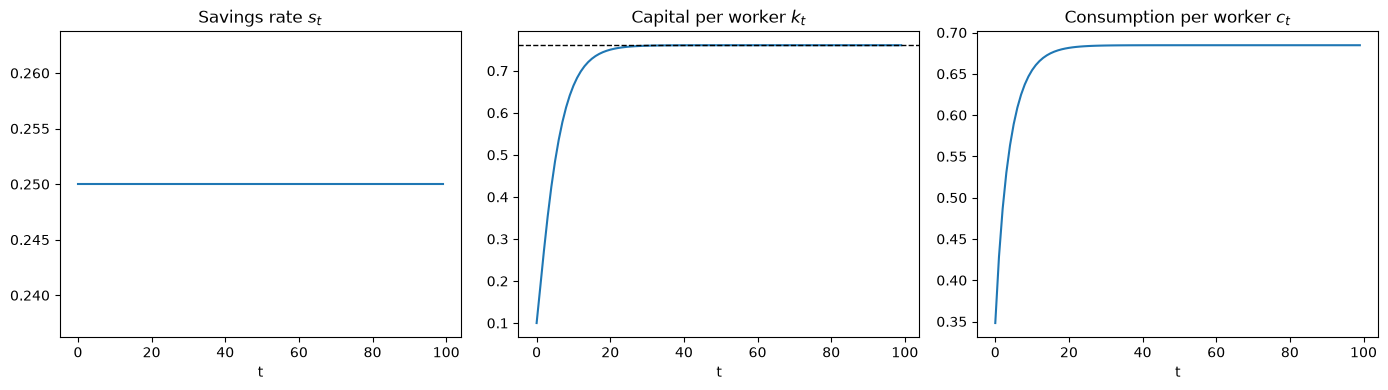

In [5]:
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t, sim.s)
axes[0].set_title('Savings rate $s_t$')

axes[1].plot(t, sim.k)
axes[1].axhline(k_star, color='black', ls='--', lw=1)  # visual check of convergence
axes[1].set_title('Capital per worker $k_t$')

axes[2].plot(t, sim.c)
axes[2].set_title('Consumption per worker $c_t$')

for ax in axes: ax.set_xlabel('t')
fig.tight_layout()
plt.show()

We see that the savings rate ($s_t$) is constant as we defined it to be. We also see, that the two other variables capital per worker ($k_t$) and consumption per worker ($c_t$) converge towards their steady state values (which we have drawn with dashed lines).

### 2.1.3
Next we try uot two different asserts which can by verified 'by hand'.

In [6]:
# 1. starting exactly at the steady state, it must stay there
sim_star = model.simulate(par.s_bar, k0=k_star)
assert np.allclose(sim_star.k, k_star), 'capital should stay at the steady state'

# 2. with s=0, capital decays geometrically: k_t = (1-delta)**t * k0 and collapses to 0
sim_zero = model.simulate(0.0)
k_formula = (1-par.delta)**t * par.k0
assert np.allclose(sim_zero.k, k_formula), 'capital should decay as (1-delta)**t * k0'

print('both checks passed')

both checks passed


Since there are no error messages and the print at the end actually works, we conclude that the simulator actually calculates the correct values and converges toward the steady state value. That is - in the first test, capital stays at the steady state and in the second test capital decays quickly towards $0$. (We use the 'allclose' statement for the comparison).

## 2.2 Question 2

### 2.2.1 
Now we implement the new savings rule. We do this by updating the 's_path(self,s0,phi)', in the SolowModel.py-module. This can be verified by the examinator at the bottom of the Python file. 


We also make sure that we can recall the baseline values and the results which depending on the combos stated in the assignment.

In [7]:
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

paths = {}

baseline = model.simulate(par.s_bar)
paths['baseline'] = dict(s=baseline.s.copy(), k=baseline.k.copy(), c=baseline.c.copy())

for s0, phi in combos:
    label = f's0={s0}, phi={phi}'
    s_t = model.s_path(s0, phi)
    result = model.simulate(s_t)
    paths[label] = dict(s=result.s.copy(), k=result.k.copy(), c=result.c.copy())

### 2.2.2 
We simulate the model and plot the variables $s_t$, $k_t$ and $c_t$ or different combinations of intial savings $s_0$ and for 'willingness to save' $\phi$ as demanded. We do this in the same panel as in Question 1.

We should have that $ \phi^t \rightarrow 0$ as $t\rightarrow \infty$, because $\phi \in [0,1)$ i.e. is smaller than one. Therefore we should also have that $s_t \rightarrow \bar{s}$ (which is also stated in the assignment).

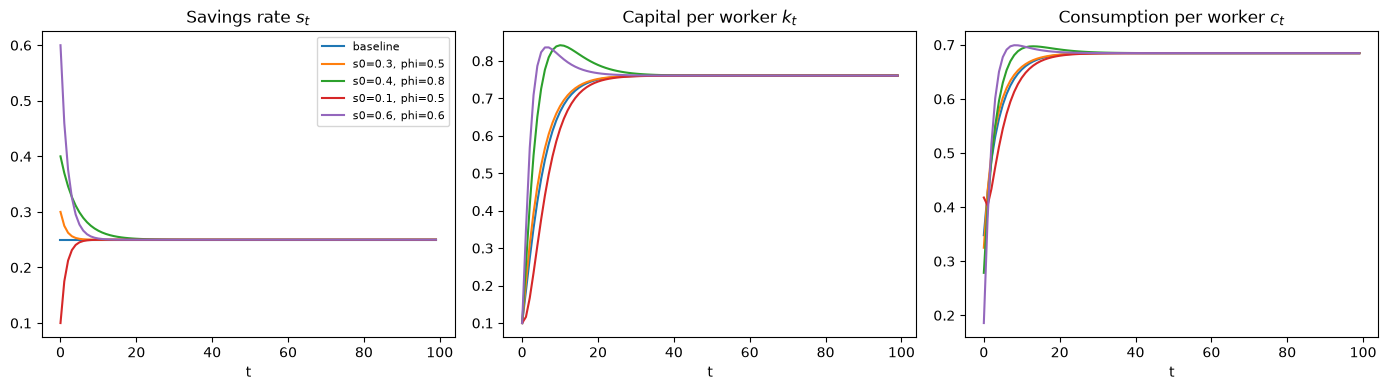

In [8]:
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for label, p in paths.items():
    axes[0].plot(t, p['s'], label=label)
    axes[1].plot(t, p['k'], label=label)
    axes[2].plot(t, p['c'], label=label)

axes[0].set_title('Savings rate $s_t$')
axes[1].set_title('Capital per worker $k_t$')
axes[2].set_title('Consumption per worker $c_t$')
for ax in axes: ax.set_xlabel('t')
axes[0].legend(fontsize=8)

fig.tight_layout()
plt.show()

We see that as expected, the savings rate converges towards a constant level. This is also true for capial per worker and consumption per worker.

### 2.2.3
We now report the value of capital per worker in the last period $T-1$ for each combination of $s_0$ and $\phi$. We expect them to be the same, as they should converge towards the same values.

In [9]:
for label, p in paths.items():
    print(f'{label:22s} k[T-1] = {p["k"][-1]:.6f}')

baseline               k[T-1] = 0.760726
s0=0.3, phi=0.5        k[T-1] = 0.760726
s0=0.4, phi=0.8        k[T-1] = 0.760726
s0=0.1, phi=0.5        k[T-1] = 0.760726
s0=0.6, phi=0.6        k[T-1] = 0.760726


We see that they have converged to the same values as expected.

### 2.2.4

We see that $s_0$ determines the level of the savings rate. The purple case where $s_0 = 0.6$ gives a high start value of saving, whereas the red case ($s_0 =0.1$) gives the opposite. A higher initial savings rate gives a higher initial level of capital pr. worker and consumption pr. worker, which can be seen in the second plot, where the green and purple path surpasses the rest of the cases. The orange and red cases has the same convergence parameters ($\phi = \tfrac12$) but the orange converges to the baseline level much faster, because it starts closer to the final level of $\bar{s} = 0.25$

Comparatively the level of $\phi$ determines the speed of convergence. A higher value of $\phi$ gives a slower convergence, as seen in $(6)$ in the assignment. The reason is that the process of $\phi^t \rightarrow 0$ will be slower for greater values of $\phi$. 

The reason why the level of capital pr. worker is higher for the green path (with $s_0 = 0.4$ and $\phi = 0.8$) is that the two effects work together. Even though the inital savings rate for purple is much higher, the high savings rate perdue for longer for the green path. This gives a savings rate which is as high (or slightly higher) than the one of the purple path.

## 2.3 Question 3

### 2.3.1
Now we implement the utility formula $W$. We do this by updating the 'stubs' 'welfare(self,c)' and 'evaluate(self,s0,phi)', in the SolowModel.py-module. This can be verified by the examinator at the bottom of the Python file. 


## 2.3.2
We report the levels of welfare in baseline, the levels of welfare in the different cases of combinations from Question 2 and the difference from the baseline case. We also insert an assert., so that we are sure that the level of investment collapses, nomatter the set level of $\phi$.

In [10]:
import pandas as pd

baseline = model.simulate(par.s_bar)
W_baseline = model.welfare(baseline.c)

# free sanity check: s0=s_bar collapses the rule to the baseline for *any* phi
assert np.isclose(model.evaluate(par.s_bar, phi=0.5), W_baseline)

combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

rows = [{'scenario': 'baseline', 's0': par.s_bar, 'phi': np.nan, 'W': W_baseline}]
for s0, phi in combos:
    W = model.evaluate(s0, phi)
    rows.append({'scenario': f's0={s0}, phi={phi}', 's0': s0, 'phi': phi, 'W': W})

table = pd.DataFrame(rows).set_index('scenario')
table['W - W_baseline'] = table['W'] - W_baseline

table.round(4)

,s0,phi,W,W - W_baseline
scenario,,,,
baseline,0.25,NaN,-3.9944,0.0000
"s0=0.3, phi=0.5",0.30,0.5,-3.9857,0.0087
"s0=0.4, phi=0.8",0.40,0.8,-4.0914,-0.0970
"s0=0.1, phi=0.5",0.10,0.5,-4.1460,-0.1516
"s0=0.6, phi=0.6",0.60,0.6,-4.3407,-0.3463


The $\phi$ in the baseline scenario is not applicable, since it uses a constant level of saving. We interpret the results in 2.3.3.

### 2.3.3

Here we see that the case which generates the largest amount of wealth, is the 'orange' one ($s_0=0.3$ and $\phi=0.5$) with an initial savings level above baseline and a -- relative to the others tested -- moderate convergence rate. The discounting $\beta^t$ of the welfare is essential to understanding this result. $\beta$ means that a higher level of consumption pr. worker is worth much more earlier than later. This means that high initial saving which 'crowds out' spending, will gnaw into the total level of welfare. 

Therefore the 'purple' og 'green' path respectively with $\textcolor{purple}{(0.4, 0.8)}$ and $\textcolor{green}{(0.6, 0.6)}$ which has graphs with generally higher levels of consumption pr. worker than the orange path in question 2, ends up with a lower overall level of welfare.

Therefore; **No, the path with highest level of welfare could not have been seen graphically in question 2**.

## 2.4 Question 4

### 2.4.1
We add the cell which calculates the level of utility as a grid, reports the best pair of initial savings rate $s_0$ and $\phi$ and the resulting welfare.

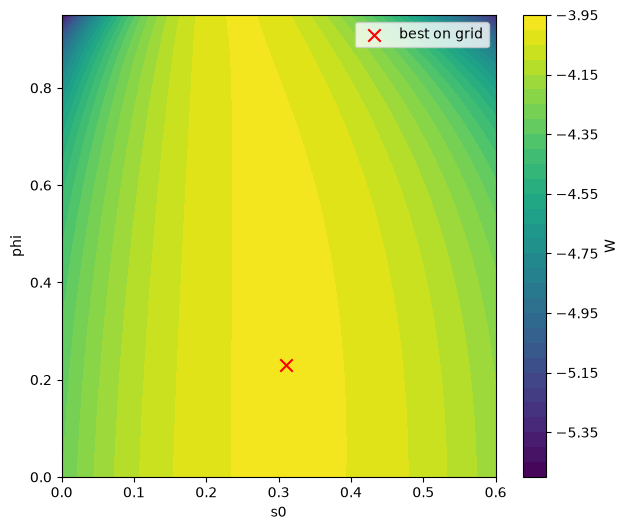

best on grid: s0=0.3100, phi=0.2300, W=-3.984306


In [11]:
# We define a grid of s0 and phi values
s0_grid = np.linspace(0, 0.60, 61)
phi_grid = np.linspace(0, 0.95, 96)

# We W on each grid point
W_grid = np.empty((len(phi_grid), len(s0_grid)))
for i, phi in enumerate(phi_grid):
    for j, s0 in enumerate(s0_grid):
        W_grid[i, j] = model.evaluate(s0, phi)

# We find the best combination on the grid
i_best, j_best = np.unravel_index(np.argmax(W_grid), W_grid.shape)
s0_best, phi_best = s0_grid[j_best], phi_grid[i_best]
W_best_grid = W_grid[i_best, j_best]

# We plot the W surface and plot the best combination
fig, ax = plt.subplots(figsize=(7, 6))
cs = ax.contourf(s0_grid, phi_grid, W_grid, levels=30)
fig.colorbar(cs, ax=ax, label='W')
ax.scatter(s0_best, phi_best, color='red', marker='x', s=80, label='best on grid')
ax.set_xlabel('s0'); ax.set_ylabel('phi'); ax.legend()
plt.show()

print(f'best on grid: s0={s0_best:.4f}, phi={phi_best:.4f}, W={W_best_grid:.6f}')

We see that the best combination is $(s_0,\phi)= (0.31,0.23)$. 
And the resulting level of welfare is $W=-3.984$.

### 2.4.2


We now run a nummerical optimizer using the Nelder-Mead method. We use a work-around which minimizes negative welfare, essentially the same as maximizing welfare. We save the optimal combination (best rule) for printout and later use.

In [12]:
from scipy import optimize

def neg_welfare(x):
    s0, phi = x
    return -model.evaluate(s0, phi)

x0 = [s0_best, phi_best]
bounds = [(0.0, 1.0), (0.0, 0.999)]   # the actual domain of (s0,phi) from eq. (6)

result = optimize.minimize(neg_welfare, x0, method='Nelder-Mead', bounds=bounds)
s0_opt, phi_opt = result.x
W_opt = -result.fun

print(f'grid:      s0={s0_best:.4f}, phi={phi_best:.4f}, W={W_best_grid:.6f}')
print(f'optimizer: s0={s0_opt:.4f}, phi={phi_opt:.4f}, W={W_opt:.6f}  (converged: {result.success})')
print(f'improvement over grid: {W_opt - W_best_grid:.6f}')

grid:      s0=0.3100, phi=0.2300, W=-3.984306
optimizer: s0=0.3115, phi=0.2208, W=-3.984300  (converged: True)
improvement over grid: 0.000006


We see that the optimizer gets the combination $(s_0,\phi)= (0.3115,0.2208)$ and the welfare level $W= -3.984300$ instead of the combination from 2.4.1: $(s_0,\phi)= (0.3100,0.2300)$ and $W= -3.984306$. 

Technically there's an imporevement by $W_{optimizer}-W_{grid}=0.000006$ units of welfare. But for all practical purposes this is negligable.

### 2.4.3

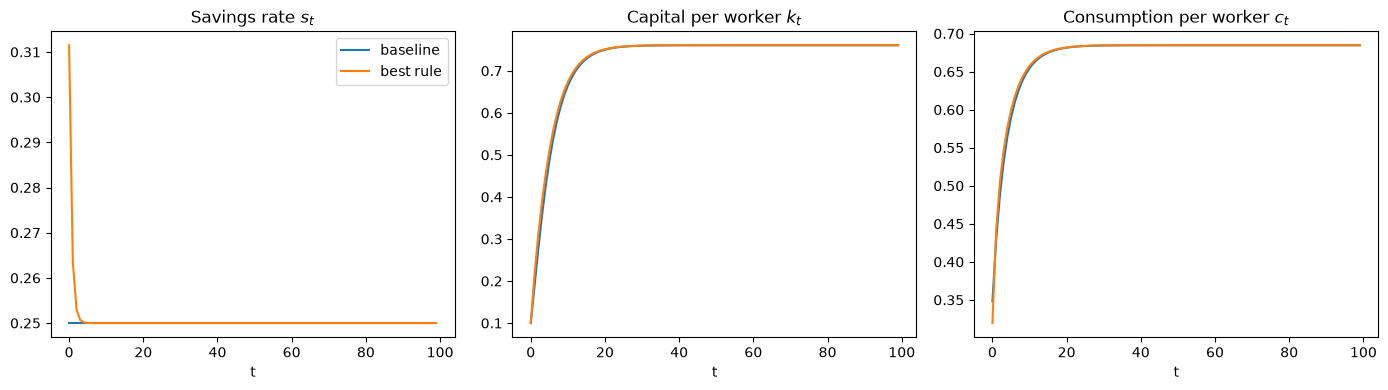

c0 (best rule) = 0.3196
first period with c_t above baseline: t = 1


In [13]:
baseline_sim = model.simulate(par.s_bar)
baseline = dict(s=baseline_sim.s.copy(), k=baseline_sim.k.copy(), c=baseline_sim.c.copy())

best_sim = model.simulate(model.s_path(s0_opt, phi_opt))
best = dict(s=best_sim.s.copy(), k=best_sim.k.copy(), c=best_sim.c.copy())

t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for label, p in [('baseline', baseline), ('best rule', best)]:
    axes[0].plot(t, p['s'], label=label)
    axes[1].plot(t, p['k'], label=label)
    axes[2].plot(t, p['c'], label=label)
axes[0].set_title('Savings rate $s_t$'); axes[1].set_title('Capital per worker $k_t$'); axes[2].set_title('Consumption per worker $c_t$')
for ax in axes: ax.set_xlabel('t')
axes[0].legend()
fig.tight_layout()
plt.show()

print(f'c0 (best rule) = {best["c"][0]:.4f}')
above = np.where(best['c'] > baseline['c'])[0]
print(f'first period with c_t above baseline: t = {above[0] if above.size else "never"}')

The consumption in period $t=0$ for the baseline was $c_{0_{baseline}} = 0.3481$ and for the best rule it is $c_{0_{best \quad rule}} = 0.3196$.
We see that the change in consumption has the biggest effect in the first periods, and soon is extinguished completely as it converges towards the steady state values.

It makes sense economically, as it is more worth it to save the capital ($s_{0_{baseline}}=0.25$ and $s_{0_{best \quad rule}}=0.3115$) for the next period, rather than using it in the production function. Therefore the consumption per worker surpases the baseline already in period $t=1$. It simply carries more capital into $t=1$. But the savings rate quickly converges towards the baseline's.

## 2.5 Question 5

### 2.5.1
To maximize in relation to three different variables, -- that is, adding $s_\infty$ -- we edit the model module and add the option to the s_path and the evaluate statements. Again we use a numerical optimizer and the Nelder-Mead method to test with both $s_\infty=\bar{s}=0.3115$ as in question 4 and with $s_\infty$ as a variable as demanded.

In [14]:
def neg_welfare3(x):
    s0, phi, s_inf = x
    return -model.evaluate(s0, phi, s_inf)

x0 = [s0_opt, phi_opt, par.s_bar]           # Q4's optimum, with s_inf starting at s_bar
bounds = [(0.0, 1.0), (0.0, 0.999), (0.0, 1.0)]

result3 = optimize.minimize(neg_welfare3, x0, method='Nelder-Mead', bounds=bounds)
s0_3, phi_3, s_inf_3 = result3.x
W_3 = -result3.fun

print(f'Question 4 (s_inf fixed at s_bar): s0={s0_opt:.4f}, phi={phi_opt:.4f}, W={W_opt:.6f}')
print(f'Question 5 (s_inf free):           s0={s0_3:.4f}, phi={phi_3:.4f}, s_inf={s_inf_3:.4f}, W={W_3:.6f}')
print(f'improvement over Q4: {W_3 - W_opt:.6f}  (converged: {result3.success})')

Question 4 (s_inf fixed at s_bar): s0=0.3115, phi=0.2208, W=-3.984300
Question 5 (s_inf free):           s0=0.3139, phi=0.6708, s_inf=0.1989, W=-3.966965
improvement over Q4: 0.017335  (converged: True)


We thereby see that the maximizing initial savings rate when $s_\infty$ is introduced is $s_0=0.3139$, $\phi=0.6708$ , the long run level itself is $s_\infty=0.1989$ and the resulting welfare is $W=-3.9669$.

### 2.5.2
Next we report the level of kapital in the last period to compare with the steady state value from question 1.

In [15]:
best3_sim = model.simulate(model.s_path(s0_3, phi_3, s_inf_3))
k_T1_best3 = best3_sim.k[-1]

k_star_new, y_star_new, c_star_new = model.steady_state(s=s_inf_3)  # steady state implied by s_inf, not s_bar

print(f'k[T-1] under the best 3-parameter rule = {k_T1_best3:.6f}')
print(f'k* from Question 1 (s = s_bar = {par.s_bar})  = {k_star:.6f}')
print(f'k* under the best 3-parameter rule = {model.steady_state(s=s_inf_3)}')

k[T-1] under the best 3-parameter rule = 0.540046
k* from Question 1 (s = s_bar = 0.25)  = 0.760726
k* under the best 3-parameter rule = (np.float64(0.5400455879522873), np.float64(0.8143482000263778), np.float64(0.6523345236406916))


We see that the steady state level of capital pr. worker from question 1 ($k^*\approx0.76$) does not correspond to the last value of capital pr. worker under the best 3-parameter rule ($k_{3par}\approx 0.54$). This is as expected, because beforehand the steady state value of capital pr. worker was determined by the savings rate. Since the saving rate in the three-parameter rule is a variable which we optimize in relation to, it is different from question 1. Therefore the level of capital pr. worker is also different, just as we observe.

## 2.6 Question 6

### 2.6.1
We change the functional form of the saving rate to 
$$s_t = s_\infty + \frac{(s_0-s_\infty)}{(1+t)^p}, \qquad \text{where } \hspace{2mm} p>0$$

To do this, we need to add new arguments to the python module. Again at the bottom of the file.

### 2.6.2
We run the model to get the new pair of $(s_0,\phi,s_\infty)$. We againg use some of the same methods as before.

In [16]:
def neg_welfare_power(x):
    s0, s_inf, p = x
    return -model.evaluate_power(s0, s_inf, p)

x0 = [s0_3, s_inf_3, 1.0]                        # reuse Q5's (s0,s_inf), start p at a neutral 1.0
bounds = [(0.0, 1.0), (0.0, 1.0), (1e-6, 50.0)]   # p>0 strictly, per your formula

result_power = optimize.minimize(neg_welfare_power, x0, method='Nelder-Mead', bounds=bounds)
s0_power, s_inf_power, p_power = result_power.x
W_power = -result_power.fun

print(f's0={s0_power:.4f}, s_inf={s_inf_power:.4f}, p={p_power:.4f}, W={W_power:.6f}  (converged: {result_power.success})')

# how close to s_inf has it actually gotten by the end of the horizon?
s_end = model.s_path_power(s0_power, s_inf_power, p_power)[-1]
print(f's_path at t=T-1: {s_end:.6f}')

s0=0.3169, s_inf=0.1622, p=0.5515, W=-3.967428  (converged: True)
s_path at t=T-1: 0.174374


Here we see that we get the wealth $W=-3.967$. Next we compare it to the results we got from the other models.

### 2.6.3


In [17]:
import pandas as pd

comparison = pd.DataFrame([
    {'rule': 'Q4: geometric, s_inf=s_bar', 'W': W_opt},
    {'rule': 'Q5: geometric, s_inf free',  'W': W_3},
    {'rule': 'Q6: own_form, s_inf free',  'W': W_power},
]).set_index('rule')

comparison['W - Q4'] = comparison['W'] - W_opt
comparison.round(6)

,W,W - Q4
rule,,
"Q4: geometric, s_inf=s_bar",-3.984300,0.000000
"Q5: geometric, s_inf free",-3.966965,0.017335
"Q6: own_form, s_inf free",-3.967428,0.016872


Here we see that we get a slightly lower increase in the level of in our own functional form ($W_{own}=-3.967428$) compared to the one in question 5 $W_5=-3.966965$ than the case was in question 5. To conclude: we weren't able to beat the level in question 5 with this partcular functional form. 

# 3. A portfolio with a risky and a safe asset

## 3.1 Question 1

### 3.1.1

In [18]:
from PortfolioModel import PortfolioModelClass
import numpy as np

# We create the portfolio model with the default parameters from the exam
model = PortfolioModelClass()
print(model)

# We draw the random shocks and turn them into gross returns R_t
R = model.draw_returns()

Portfolio model with:
  mu    = 0.0500, sigma = 0.2000, r = 0.0100
  theta_star = 0.5000, Delta = 0.1000, tau = 0.0100
  gamma = 3.0000 (relative risk aversion)
  W0 = 1.00, T = 40, N = 50,000, seed = 2026


### 3.1.2

In [19]:
par = model.par
logR = np.log(R)

# We compare the simulated mean and standard deviation of log R with mu and sigma
print(f'mean of log R = {logR.mean():.4f}, mu    = {par.mu:.4f}')
print(f'std of log R  = {logR.std():.4f}, sigma = {par.sigma:.4f}')

# We compare the simulated mean of R with the closed-form mean of a log-normal variable
print(f'mean of R          = {R.mean():.4f}')
print(f'exp(mu + 0.5*sig2) = {np.exp(par.mu + 0.5*par.sigma**2):.4f}')

mean of log R = 0.0500, mu    = 0.0500
std of log R  = 0.2000, sigma = 0.2000
mean of R          = 1.0725
exp(mu + 0.5*sig2) = 1.0725


We see that the mean of $R_t$ and $\exp(\mu+\frac{1}{2}\sigma^2)$ are equal, which is the expected result. 
$\log(R_t)$ is normal by construction, and for a normal variable, the mean of $\exp(X)$ is always $\exp(\mu +\frac{1}{2}\sigma^2)$ rather than $\exp(\mu)$, since $\exp$ is convex. The simulated mean lining up with the formula just confirms the returns are being drawn correctly.

### 3.1.3

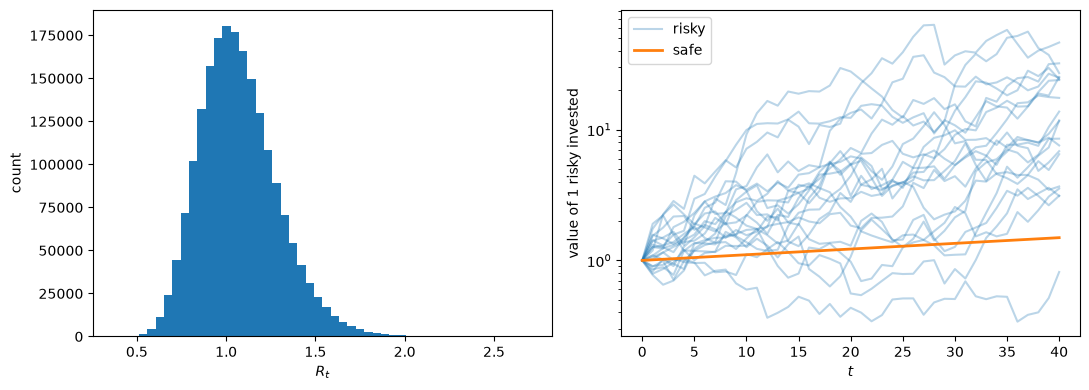

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot a histogram of all the simulated gross returns
axes[0].hist(R.flatten(), bins=50)
axes[0].set_xlabel('$R_t$')
axes[0].set_ylabel('count')

# We compute the value of 1 invested in the risky asset, for 20 portfolios, and in the safe asset
value_risky = np.concatenate([np.ones((20, 1)), np.cumprod(R[:20], axis=1)], axis=1)
value_safe = np.exp(par.r * np.arange(par.T + 1))

# We plot both, on a logarithmic scale so the paths stay comparable
for i in range(20):
    axes[1].plot(value_risky[i], color='C0', alpha=0.3, label='risky' if i == 0 else None)
axes[1].plot(value_safe, color='C1', lw=2, label='safe')
axes[1].set_yscale('log')
axes[1].set_xlabel('$t$')
axes[1].set_ylabel('value of 1 risky invested')
# We add a legend to the second plot
axes[1].legend()
plt.tight_layout()
plt.show()

We can see that the histogram isn't symmetrical, as it is slightly right-skewed. This implies that 

Almost all of the 20 risky asset portfolios end up having a higher value than the safe asset. Theres only 1 portfolio that winds up having a lesser value than the safe asset in the last period, which is the only period that our investor cares about. When looking at a long time period such as this one, most of the bad draws get evened out by more good draws, which is why the risky asset mosly outperformes the safe asset

## 3.2 Question 2

### 3.2.1

In [21]:
# We run the simulator once with the default (baseline) rule, reusing the returns from Question 1
model.simulate(R=R)

print(model.sim.W.shape)
print(model.sim.theta.shape)

(50000, 41)
(50000, 41)


### 3.2.2

In [22]:
import pandas as pd

# We set up the two extreme rules, with no transaction costs
rules = {
    'Delta=0': PortfolioModelClass(tau=0.0, Delta=0.0),
    'Delta=1': PortfolioModelClass(tau=0.0, Delta=1.0),
}

# We simulate both on the exact same drawn returns
for m in rules.values():
    m.simulate(R=R)

# We collect the six numbers for each rule in one table
rows = []
for name, m in rules.items():
    rows.append({'rule': name, **m.summary()})

pd.DataFrame(rows)

,rule,trades,distance,mean WT,median WT,10th pct WT,E[u(WT)]
0,Delta=0,39.0,0.039395,5.043602,4.081492,1.793667,-0.067829
1,Delta=1,0.0,0.191138,8.975620,4.447803,1.485479,-0.076690


As expected, when $\Delta=1$, there are 0 trades, as $\theta_t-\theta^*<1$ and therefore $\theta_t-\theta^*<\Delta$ for $0<\theta_t<1$

### 3.2.3

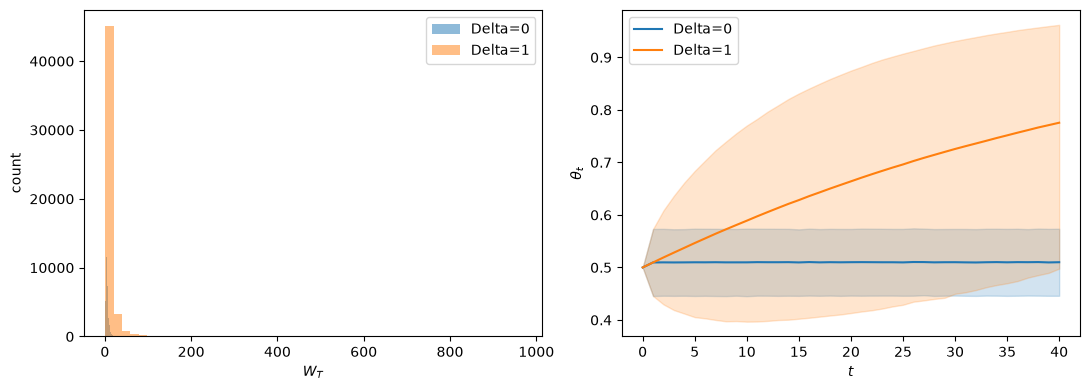

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot a histogram of terminal wealth for both rules
for name, m in rules.items():
    axes[0].hist(m.sim.W[:, -1], bins=50, alpha=0.5, label=name)
axes[0].set_xlabel('$W_T$')
axes[0].set_ylabel('count')
axes[0].legend()

# We plot the mean risky share over time, with a shaded 10th-90th percentile band
t = np.arange(par.T + 1)
for name, m in rules.items():
    mean_theta = m.sim.theta.mean(axis=0)
    p10 = np.percentile(m.sim.theta, 10, axis=0)
    p90 = np.percentile(m.sim.theta, 90, axis=0)

    line, = axes[1].plot(t, mean_theta, label=name)
    axes[1].fill_between(t, p10, p90, color=line.get_color(), alpha=0.2)

axes[1].set_xlabel('$t$')
axes[1].set_ylabel(r'$\theta_t$')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.2.4

We can see that the mean share of $\theta_t$, represented by the orange line, grows steadily throughout the timeperiod. The 10th percentile almost has the same share of $\theta_t$ as the portofolio of $\Delta=1$ where $\theta_t=0.5$, and the 90th percentile has a far higher share , at around $\theta_t=0.95$.

In the case where $\Delta$=1 (where 0 trades are being made), the investor keeps the same portfolio that she has at $t_0$ where she has an equal amount of units in each asset, implying $\theta_t=1-\theta_t=0.5$ at $t_0$. This means that the change in the share of $\theta_t$ purely comes from the fluctuations in the risky asset. If $\theta_t>1-\theta_t$ then the risky asset has cumulatively outperformed the safe asset, and if $\theta_t<1-\theta_t$ the safe asset has cumulatively outperformed the risky asset. 
$\theta_t>0.5$ in the vast majority of cases, which means that it is cumulatively outperforming the safe asset. 

We can also see the same underlying cause in the graph in 3.1.3, where the simulation of the 20 portfolios shows almost the same tendency as the graph in 3.2.3. That is, the risky asset mostly outperforms the safe asset - implying that $\theta_t>1-\theta_t$.

## 3.3 Question 3

### 3.3.1

In [24]:
Deltas = [0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 1]

# We simulate every band width with the same transaction cost and the same drawn returns
rows = []
for Delta in Deltas:
    m = PortfolioModelClass(tau=0.01, Delta=Delta)
    m.simulate(R=R)
    rows.append({'Delta': Delta, **m.summary()})

df_delta = pd.DataFrame(rows).set_index('Delta')
df_delta

,trades,distance,mean WT,median WT,10th pct WT,E[u(WT)]
Delta,,,,,,
0.000,39.00000,0.039395,4.962427,4.018396,1.768274,-0.069934
0.025,24.52346,0.039974,4.974622,4.018379,1.769181,-0.069745
0.050,14.33342,0.042948,5.015482,4.035755,1.767369,-0.069505
0.075,8.79048,0.047986,5.073901,4.047645,1.765500,-0.069347
0.100,5.86028,0.054052,5.145886,4.060641,1.759388,-0.069460
0.150,3.15190,0.068029,5.328542,4.104170,1.735272,-0.069950
0.200,1.95026,0.083468,5.559645,4.186286,1.679246,-0.070944
0.300,0.90548,0.117972,6.195680,4.341368,1.536125,-0.073406
1.000,0.00000,0.191138,8.975620,4.447803,1.485479,-0.076690


### 3.3.2

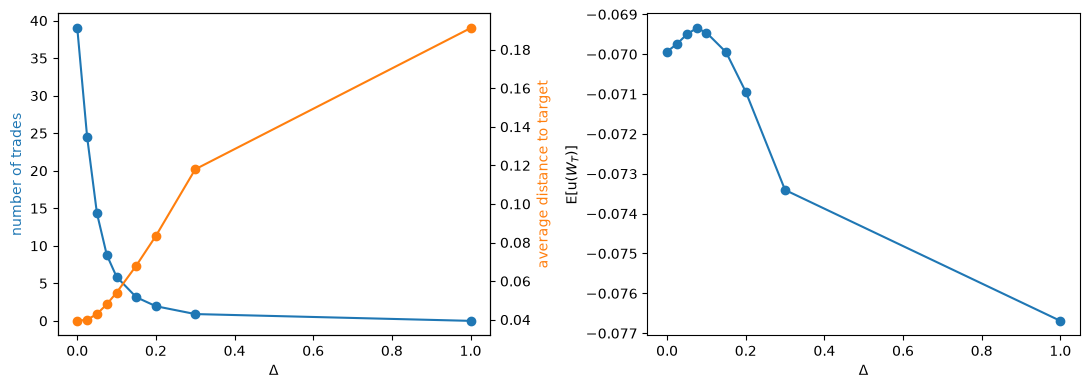

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# We plot the number of trades and the average distance to target against Delta, on two y-axes
ax2 = axes[0].twinx()
axes[0].plot(df_delta.index, df_delta['trades'], color='C0', marker='o', label='trades')
ax2.plot(df_delta.index, df_delta['distance'], color='C1', marker='o', label='distance')
axes[0].set_xlabel(r'$\Delta$')
axes[0].set_ylabel('number of trades', color='C0')
ax2.set_ylabel('average distance to target', color='C1')

# We plot expected utility against Delta
axes[1].plot(df_delta.index, df_delta['E[u(WT)]'], marker='o')
axes[1].set_xlabel(r'$\Delta$')
axes[1].set_ylabel('E[u($W_T$)]')

plt.tight_layout()
plt.show()

### 3.3.3

In [26]:
# We use the method idxmax to find the index of the maximum expected utility, and max to find the maximum value itself
best_Delta = df_delta['E[u(WT)]'].idxmax()
best_EU = df_delta['E[u(WT)]'].max()

# We compare the best Delta with the two extremes from Question 2
print(f'best Delta = {best_Delta}, E[u(WT)] = {best_EU:.4f}')
print(f'improvement over Delta=0: {best_EU - df_delta.loc[0, "E[u(WT)]"]:.4f}')
print(f'improvement over Delta=1: {best_EU - df_delta.loc[1, "E[u(WT)]"]:.4f}')

best Delta = 0.075, E[u(WT)] = -0.0693
improvement over Delta=0: 0.0006
improvement over Delta=1: 0.0073


The best $\Delta$ in terms of the expected utility of the investor is 0.075 with $E[u(W_T)]=-0.0693$. This only  marginaly outperforms $\Delta=0$ by 0.0006, whereas it outperforms $\Delta=1$ by 0.0073

### 3.3.4

As $\Delta$ grows, so do the distance between $\theta_t$ and $\theta^*$, the mean of $W_T$ and the median of $W_T$. The number of trades and the 10th percentiles wealth fall as $\Delta$ grows, and when $\Delta>0.075$, the expected utility is diminishing for larger $\Delta$

When $\Delta$ is going from 0 to the best $\Delta$ (0.075), the number of trades change quite a bit - from 39 to right under 9. It makes sense that number of trades decrease as the no-trade band increases. The only other number that changes by a noteable amount is the difference between $\theta_t$ and $\theta^*$. Otherwise the numbers only change marginally 

If the different outcomes instead were ordered by the mean wealth, it would not be optimal to chose the same rule as above. We can reuse the above code to find the $\Delta$ that generates the highest mean wealth empirically. 

In [ ]:
#We want to find the Delta that maximizes the mean wealth at the end of the investment horizon, WT. We can do this by using the idxmax method to find the index of the maximum mean WT, and max to find the maximum value itself.
best_Delta_mean_WT = df_delta['mean WT'].idxmax()
print(f'best Delta for mean WT = {best_Delta_mean_WT}, mean WT = {df_delta.loc[best_Delta_mean_WT, "mean WT"]:.4f}')

best Delta for mean WT = 1.0, mean WT = 8.9756


The best $\Delta$ when we want to maximize the mean wealth is $\Delta=1$ - it is actually also the $\Delta$ that maximizes the median wealth. This means the we should change our rule if it was ranked by mean or median. 

The expected utility function reveals that we shouldn't just look at the median and mean to make our investment decision. Mean and median mostly look in the middle of the distrubition, and the expected utility looks at all the outcomes. 

$u(W) =\frac{W^{1−γ}}{1−γ}$ with $\gamma=3$ is concave, implying that there's diminishing marginal utility. $\gamma$ is an expression of the risk aversion of our investor, which is a factor that should be taken into account. $\gamma=3$ means that our investor is relatively risk averse, as she gets less utility even though the mean and median are higher. This implies that she cares more about the negative outcomes in terms of return rather than the positive outcomes. 